# Classification Models: From Binary Diagnosis to Multiclass Prediction

---

> ### 📋 Practice Exercise. Not Graded.
> This is a **practice assignment** for self-assessment. The marks shown throughout are **indicative only**. They tell you where to spend your effort and where you might need more practice. **None of these marks count towards your final grade.**
>
> Attempt every section. Compare your results. Revisit what trips you up.

---

## What You Will Build

Two classifiers, two datasets, one progression from simple to complex.

| Part | Dataset | Task | Primary Metric |
|------|---------|------|----------------|
| **Part 1** | Breast Cancer (sklearn) | Binary: Malignant vs Benign | Recall (Sensitivity) |
| **Part 2** | Wine (sklearn) | Multiclass: 3 wine cultivars | Macro-averaged F1-Score |

**Indicative Marks: 100** (Part 1: 55 | Part 2: 45)

### Before You Start
- Complete all cells marked with `# TODO`.
- Markdown cells marked **[Your Answer]** need written responses. Don't skip them.
- Run `Runtime > Restart and run all` before reviewing. The notebook should execute top to bottom without errors.
- Use `random_state=42` wherever a function accepts it. This keeps your results reproducible.


---
# PART 1: Binary Classification, Breast Cancer Prediction

## Context

Early detection of malignant tumours saves lives. In this part, you will build classifiers that predict whether a breast tumour is **malignant** or **benign** based on features computed from cell nuclei images.

**Why Recall matters here:** A false negative means telling a patient their tumour is benign when it is actually malignant. That is a missed cancer diagnosis. A false positive means an unnecessary follow-up test. Annoying, but survivable. The asymmetry is stark: we prioritise **recall for the malignant class** above everything else.

> **Clinical Constraint:** We want recall ≥ 0.95 for malignant cases, while keeping precision ≥ 0.60 (i.e., not flooding clinics with false alarms).


## Stage 1: Data and Package Loading

<font color="red">**[3 marks]**</font>

Load the Breast Cancer Wisconsin dataset from `sklearn.datasets`.

**What to do:**
- The libraries below are pre-imported. Review them, add anything else you need.
- Load the dataset using `load_breast_cancer()`
- Convert it to a DataFrame with proper column names
- Separate features (`X`) and target (`y`)

> **Watch out:** In the raw dataset, `0 = malignant` and `1 = benign`. Since `recall_score` defaults to `pos_label=1`, we need malignant to be 1. **Remap the target** with `y = 1 - data.target`.


In [1]:
# Pre-imported libraries. Review these, add what you need below.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, precision_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, roc_auc_score,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load the breast cancer dataset and convert to DataFrame
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Separate features and target, remap so malignant = 1
X = df
y = 1 - data.target  # flip labels: 0=malignant -> 1, 1=benign -> 0

## Stage 2: Data Understanding

<font color="red">**[8 marks]**</font>

Before building any model, understand the data.


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the first few rows, check the shape, data types, and confirm there are no missing values.


In [4]:
# Display first 5 rows
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
# Check shape, data types, and missing values
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print()
print("Data types in X:")
print(df.dtypes.value_counts())
print()
print("Missing values in X:", df.isnull().sum().sum())
print("Missing values in y:", pd.Series(y).isnull().sum())

Shape of X: (569, 30)
Shape of y: (569,)

Data types in X:
float64    30
Name: count, dtype: int64

Missing values in X: 0
Missing values in y: 0


### 2.2 Summary Statistics <font color="red">[2 marks]</font>

Generate descriptive statistics. Pay attention to the **scale differences** across features. Some features range in the hundreds, others below 1. This matters for your preprocessing choices.


In [6]:
# Summary statistics
# Note the scale differences: mean radius is ~14, mean area is ~654, mean fractal dimension is ~0.06
### CODE HERE ###
df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 2.3 Class Distribution <font color="red">[2 marks]</font>

How many malignant vs benign cases are there? Visualise this with a bar plot.


0    357
1    212
Name: count, dtype: int64


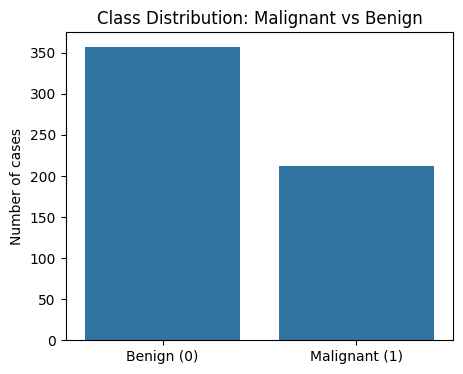

In [7]:
# Class distribution after remapping
class_counts = pd.Series(y).value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=["Benign (0)", "Malignant (1)"], y=class_counts.values)
plt.ylabel("Number of cases")
plt.title("Class Distribution: Malignant vs Benign")
plt.show()

### 2.4 Feature Distributions <font color="red">[2 marks]</font>

Pick 4-6 features and plot their distributions using histograms or boxplots. Look for skewness, outliers, and whether the two classes separate visually on any feature.


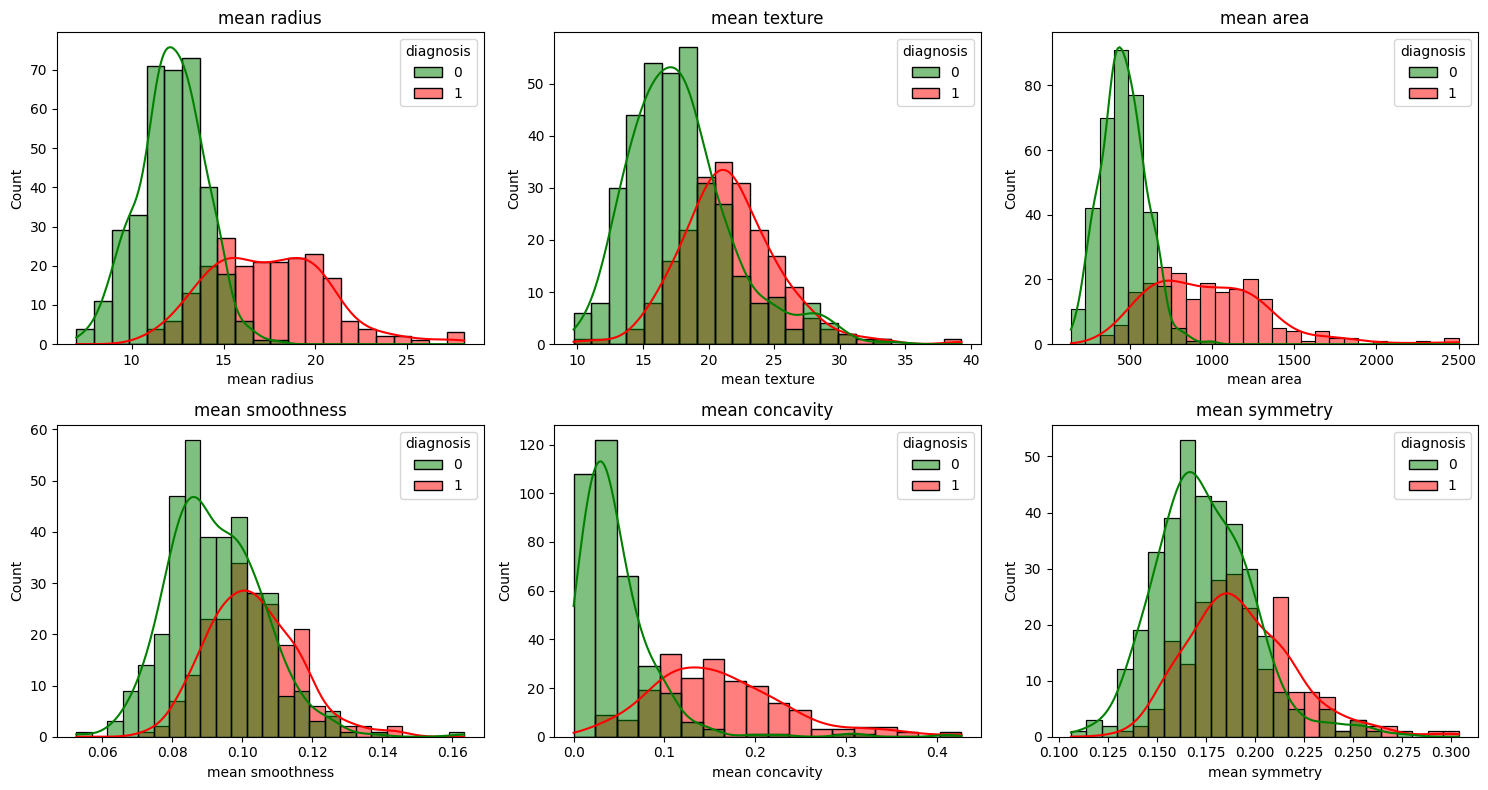

In [8]:
# Feature distributions for 6 selected features, coloured by class
features_to_plot = ["mean radius", "mean texture", "mean area",
                     "mean smoothness", "mean concavity", "mean symmetry"]

plot_df = X.copy()
plot_df["diagnosis"] = y

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(data=plot_df, x=feature, hue="diagnosis", kde=True, ax=axes[i], palette=["green", "red"])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()


### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer these questions in 2-3 sentences each:
1. Is the dataset balanced? How might imbalance affect model training?
2. Do the features have similar scales? What does this mean for models like KNN and SVM?
3. Why is recall a better primary metric than accuracy for this problem?
4. Why must we fit the scaler on training data only and not on the full dataset? What information from the test set would leak into training if we did?


*Write your answers here:*

1. The dataset is mildly imbalanced — 357 benign (63%) vs 212 malignant (37%). Not extreme, but enough that a model could look deceptively good by leaning toward predicting the majority class (benign) while still quietly missing a chunk of the malignant cases.

2. No — the scales are wildly different. Looking at the charts: mean smoothness sits roughly in the 0.06–0.16 range, but mean area stretches all the way to ~2500. Distance-based models like KNN  and SVM (finds margins between points) both work by literally calculating numeric distances between data points. If we feed them raw, unscaled data, a feature like mean area would dominate that distance math purely because its numbers are bigger — not because it's actually more medically important than mean smoothness.

3. Because the two possible mistakes aren't equally bad. A false negative (calling a malignant tumor "benign") means a missed cancer diagnosis — potentially life-threatening. A false positive (calling a benign tumor "malignant") just triggers an unnecessary follow-up test — annoying, but not dangerous. Accuracy treats both mistakes as equally costly, and on an imbalanced dataset it can be flat-out misleading (see point 1 — always guessing "benign" nets ~63% accuracy with 0% cancer detection). Recall specifically measures "of all the real malignant cases, how many did we actually catch" — which is the number that matters clinically.

4.  A scaler "learns" its rescaling rule (the mean and standard deviation it subtracts/divides by) from whatever data you fit it on. If you fit it on the full dataset (train + test combined), that rule is now partly shaped by the test set's own statistics — meaning our training data gets transformed using information that peeked at the test set. That's data leakage: the model is indirectly getting a preview of the test set's distribution before it's ever supposed to see it, which makes your test performance look artificially better than it would on genuinely new, real-world patients.


## Stage 3: Data Preprocessing and Preparation

<font color="red">**[7 marks]**</font>


### 3.1 Missing Value Audit <font color="red">[1 mark]</font>

Confirm no missing values exist. If any do, handle them with median imputation.


In [9]:
# Missing value audit
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()

print("Total missing values in X:", total_missing)
print("Missing values in y:", pd.Series(y).isnull().sum())

if total_missing > 0:
    print("\nColumns with missing values:")
    print(missing_counts[missing_counts > 0])
    df = df.fillna(df.median())
    print("\nMissing values filled with column median.")
else:
    print("\nNo missing values found. Nothing to impute.")


Total missing values in X: 0
Missing values in y: 0

No missing values found. Nothing to impute.


### 3.2 Train-Test Split <font color="red">[2 marks]</font>

Split into 70% training and 30% test using **stratified sampling** to preserve the class ratio to mitigate any slight class imbalance. Use `random_state=42`.


In [10]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)


### 3.3 Feature Scaling <font color="red">[2 marks]</font>

Apply `StandardScaler`. **Fit the scaler on training data only**, then transform both train and test sets. If you fit on the full dataset, the scaler learns the mean and standard deviation of the test data, which inflates your results. That is data leakage.

> **Note:** Decision Trees split on thresholds and don't need scaling. But for consistency here, we scale for all models.


In [11]:
# Feature scaling: fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### 3.4 Confirm Prepared Data <font color="red">[2 marks]</font>

Print shapes of your final training and test sets. Verify the class distribution is preserved in both.


In [12]:
# Confirm prepared data
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print()
print("Training set class distribution (proportion):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
print()
print("Test set class distribution (proportion):")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())


X_train_scaled shape: (398, 30)
X_test_scaled shape: (171, 30)
y_train shape: (398,)
y_test shape: (171,)

Training set class distribution (proportion):
0    0.628141
1    0.371859
Name: proportion, dtype: float64

Test set class distribution (proportion):
0    0.625731
1    0.374269
Name: proportion, dtype: float64


## Helper: Evaluation Function

You will evaluate many models. Rather than copy-pasting the same five lines every time, define a reusable function. Call it throughout Stages 4-6.


In [13]:
# Helper function. Use this to evaluate all models consistently.
def evaluate_model(name, y_true, y_pred, average="binary"):
    print(f"===== {name} =====")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, average=average), 4))
    print("Recall   :", round(recall_score(y_true, y_pred, average=average), 4))
    print("F1-score :", round(f1_score(y_true, y_pred, average=average), 4))
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))


## How GridSearchCV Works

If you haven't used `GridSearchCV` before, read this before moving on.

`GridSearchCV` automates hyperparameter tuning. You give it a set of parameter values to try, and it trains a model for every combination, scores each one using cross-validation, and tells you which combination won.

You can refer to the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

Here is the pattern you will repeat for every model below:

```python
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# 1. Define what parameter values to try
param_grid = {'C': [0.1, 1, 10]}

# 2. Set up GridSearchCV
grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=10000),
    param_grid=param_grid,
    scoring='recall',   # what metric to optimise
    cv=5,               # 5-fold cross-validation on training data
    n_jobs=-1            # use all CPU cores
)

# 3. Fit on training data
grid.fit(X_train_scaled, y_train)

# 4. Check results
print("Best parameters:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_

# 5. Predict on test set
y_pred = best_model.predict(X_test_scaled)
```

Every model below follows the same five steps. The only things that change are the estimator and the parameter grid.


## Stage 4: Model Training, Hyperparameter Tuning, and Evaluation

<font color="red">**[23 marks]**</font>

Train **four classifiers**, tune them, evaluate each one.

For each model:
1. Define the parameter grid
2. Run `GridSearchCV` with `scoring='recall'`, `cv=5`
3. Print the best parameters
4. Predict on the test set using the best estimator
5. Evaluate using `evaluate_model()`

> We use `scoring='recall'` because our goal is to catch malignant cases. Accuracy is misleading when classes are imbalanced.


### 4.1 Logistic Regression (Baseline) <font color="red">[5 marks]</font>

Logistic Regression with `class_weight='balanced'` to handle class imbalance.

**Hyperparameters to tune:**
- `C`: Regularisation strength. Try `[0.01, 0.1, 1, 10, 100]`
- Set `max_iter=10000` and `random_state=42`


In [14]:
# Logistic Regression with GridSearchCV
lr_grid = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=10000, random_state=42),
    param_grid={"C": [0.01, 0.1, 1, 10, 100]},
    scoring="recall",
    cv=5,
    n_jobs=-1,
)
lr_grid.fit(X_train_scaled, y_train)

print("Best parameters:", lr_grid.best_params_)
print("Best CV recall:", round(lr_grid.best_score_, 4))
best_lr = lr_grid.best_estimator_

Best parameters: {'C': 10}
Best CV recall: 0.9389


In [15]:
# Evaluate LR on test set
y_pred_lr = best_lr.predict(X_test_scaled)
evaluate_model("Logistic Regression", y_test, y_pred_lr)


===== Logistic Regression =====
Accuracy : 0.9708
Precision: 0.9836
Recall   : 0.9375
F1-score : 0.96
Confusion matrix:
[[106   1]
 [  4  60]]


### 4.2 K-Nearest Neighbours (KNN) <font color="red">[6 marks]</font>

[KNN](https://scikit-learn.org/stable/modules/neighbors.html) classifies a sample by majority vote of its nearest neighbours. Sensitive to feature scale, which is why we scaled the data.

**Hyperparameters to tune:**
- `n_neighbors`: Try `[3, 5, 7, 9, 11, 15]`
- `weights`: Try `['uniform', 'distance']`. Uniform gives equal votes. Distance gives closer neighbours more influence.

> Think about it: if malignant samples are sparse in a local neighbourhood, why might `weights='distance'` help?


In [16]:
# KNN with GridSearchCV
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
    },
    scoring="recall",
    cv=5,
    n_jobs=-1,
)
knn_grid.fit(X_train_scaled, y_train)

print("Best parameters:", knn_grid.best_params_)
print("Best CV recall:", round(knn_grid.best_score_, 4))
best_knn = knn_grid.best_estimator_


Best parameters: {'n_neighbors': 7, 'weights': 'uniform'}
Best CV recall: 0.9253


In [17]:
# Evaluate KNN on test set
y_pred_knn = best_knn.predict(X_test_scaled)
evaluate_model("KNN", y_test, y_pred_knn)


===== KNN =====
Accuracy : 0.9649
Precision: 1.0
Recall   : 0.9062
F1-score : 0.9508
Confusion matrix:
[[107   0]
 [  6  58]]


### 4.3 Decision Tree <font color="red">[6 marks]</font>

[Decision Trees](https://scikit-learn.org/stable/modules/tree.html) split features at thresholds. Without constraints, they memorise training data perfectly and fail on new data. That is overfitting.

**Hyperparameters to tune:**
- `max_depth`: Try `[3, 5, 7, 10, None]`. `None` means no limit.
- `min_samples_split`: Try `[2, 5, 10]`
- `min_samples_leaf`: Try `[1, 2, 4]`
- Use `class_weight='balanced'` and `random_state=42`


In [18]:
# Decision Tree with GridSearchCV
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid={
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    scoring="recall",
    cv=5,
    n_jobs=-1,
)
dt_grid.fit(X_train_scaled, y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best CV recall:", round(dt_grid.best_score_, 4))
best_dt = dt_grid.best_estimator_


Best parameters: {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV recall: 0.932


In [19]:
# Evaluate Decision Tree on test set
y_pred_dt = best_dt.predict(X_test_scaled)
evaluate_model("Decision Tree", y_test, y_pred_dt)


===== Decision Tree =====
Accuracy : 0.9064
Precision: 0.9
Recall   : 0.8438
F1-score : 0.871
Confusion matrix:
[[101   6]
 [ 10  54]]


### 4.4 Support Vector Machine (SVM) <font color="red">[6 marks]</font>

[SVMs](https://scikit-learn.org/stable/modules/svm.html) find the hyperplane that separates classes with the widest margin. With kernel functions, they can model non-linear boundaries.

**Hyperparameters to tune:**
- `C`: Try `[0.1, 1, 10]`
- `kernel`: Try `['linear', 'rbf']`. Linear for linearly separable data, RBF for non-linear.
- `gamma`: Try `['scale', 'auto']` (matters for RBF kernel)
- Use `class_weight='balanced'`, `random_state=42`, and `probability=True`

> **Why `probability=True`?** We need `predict_proba()` for threshold tuning in Stage 6.


In [20]:
# SVM with GridSearchCV
svm_grid = GridSearchCV(
    estimator=SVC(class_weight="balanced", probability=True, random_state=42),
    param_grid={
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"],
    },
    scoring="recall",
    cv=5,
    n_jobs=-1,
)
svm_grid.fit(X_train_scaled, y_train)

print("Best parameters:", svm_grid.best_params_)
print("Best CV recall:", round(svm_grid.best_score_, 4))
best_svm = svm_grid.best_estimator_


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV recall: 0.952


In [21]:
# Evaluate SVM on test set
y_pred_svm = best_svm.predict(X_test_scaled)
evaluate_model("SVM", y_test, y_pred_svm)


===== SVM =====
Accuracy : 0.9825
Precision: 0.9841
Recall   : 0.9688
F1-score : 0.9764
Confusion matrix:
[[106   1]
 [  2  62]]


## Stage 5: Model Comparison

<font color="red">**[9 marks]**</font>


### 5.1 Build a Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all four models on the **test set**:
- Accuracy
- Recall (for malignant class)
- Precision (for malignant class)
- F1-Score (for malignant class)
- Number of False Negatives (from confusion matrix)

> **Hint:** A false negative is a malignant case predicted as benign. In the confusion matrix, it sits at position `[1][0]` when malignant = 1.


In [22]:
# Comparison table for all 4 models
predictions = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Decision Tree": y_pred_dt,
    "SVM": y_pred_svm,
}

rows = []
for name, y_pred in predictions.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "False Negatives": confusion_matrix(y_test, y_pred)[1][0],
    })

comparison_df = pd.DataFrame(rows).round(4)
comparison_df



,Model,Accuracy,Recall,Precision,F1,False Negatives
0,Logistic Regression,0.9708,0.9375,0.9836,0.9600,4
1,KNN,0.9649,0.9062,1.0000,0.9508,6
2,Decision Tree,0.9064,0.8438,0.9000,0.8710,10
3,SVM,0.9825,0.9688,0.9841,0.9764,2


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Create a grouped bar chart comparing Recall and Precision across all four models.


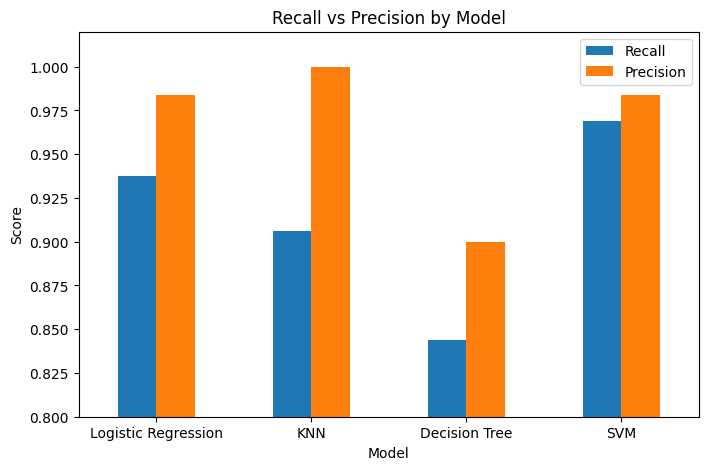

In [23]:
# Grouped bar chart: Recall and Precision
comparison_df.plot(x="Model", y=["Recall", "Precision"], kind="bar", figsize=(8, 5))
plt.ylim(0.8, 1.02)
plt.ylabel("Score")
plt.title("Recall vs Precision by Model")
plt.xticks(rotation=0)
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[2 marks]</font>

For **all four models**, run 5-fold stratified [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html) on the **training set** using `cross_val_score` with `scoring='recall'`. Print the mean and standard deviation of recall for each.

> **Why this matters:** High recall on one split means nothing if the model collapses on another. Stability tells you whether you can trust the number.

> **A caveat:** You are running `cross_val_score` on already-tuned estimators. This is a quick stability check, not a substitute for nested cross-validation. Good enough for a practice exercise.


In [24]:
# Cross-validation stability for all 4 models
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_models = {
    "Logistic Regression": best_lr,
    "KNN": best_knn,
    "Decision Tree": best_dt,
    "SVM": best_svm,
}

for name, model in best_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="recall")
    print(f"{name:<20} mean recall = {scores.mean():.4f}   std = {scores.std():.4f}")


Logistic Regression  mean recall = 0.9524   std = 0.0175
KNN                  mean recall = 0.9251   std = 0.0511
Decision Tree        mean recall = 0.8782   std = 0.0724
SVM                  mean recall = 0.9524   std = 0.0279


### 5.4 Feature Importance <font color="red">[2 marks]</font>

Knowing *which features drive predictions* matters as much as the predictions themselves.

- Extract **feature importances** from your best Decision Tree (`.feature_importances_`) or **coefficients** from Logistic Regression (`.coef_[0]`)
- Plot the **top 10 most important features** as a horizontal bar chart


worst perimeter         0.7635
worst concave points    0.0960
mean texture            0.0344
area error              0.0313
worst smoothness        0.0223
worst concavity         0.0162
symmetry error          0.0115
worst area              0.0114
worst symmetry          0.0085
worst texture           0.0049
dtype: float64


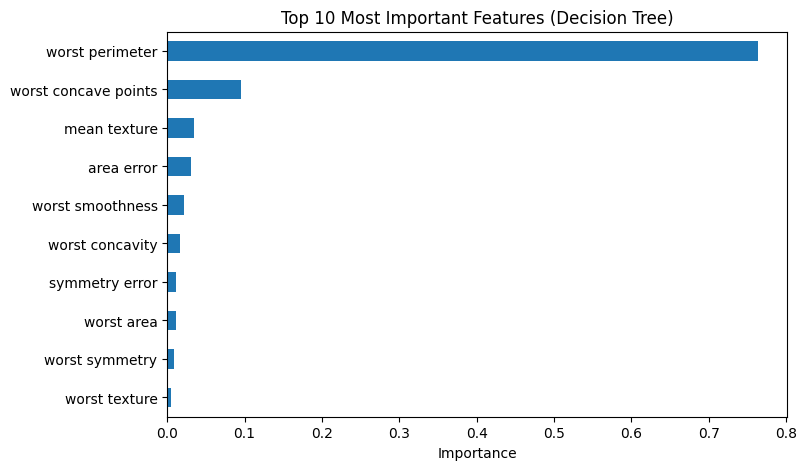

In [25]:
# Feature importance from Decision Tree
importances = pd.Series(best_dt.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)
print(top10.round(4))

top10.sort_values().plot(kind="barh", figsize=(8, 5))
plt.xlabel("Importance")
plt.title("Top 10 Most Important Features (Decision Tree)")
plt.show()


## Stage 6: Final Model Selection

<font color="red">**[5 marks]**</font>


### 6.1 Threshold Tuning <font color="red">[2 marks]</font>

By default, classifiers use a probability threshold of 0.5 to assign classes. For medical diagnosis, we can lower this threshold to catch more malignant cases (higher recall) at the cost of more false positives (lower precision).

**Steps:**
1. Create a **stratified validation split from your training data** (70/30 from `X_train_scaled`). Do not touch the test set for this.
2. Retrain your best model on the inner training portion
3. Get predicted probabilities on the validation portion using `predict_proba()`
4. Plot the **precision-recall curve**
5. Find a threshold where recall ≥ 0.95

> **Why not tune on the test set?** If you use the test set to pick a threshold, your final evaluation on that same test set is no longer honest. The test set becomes a tuning surface, and your reported metrics are optimistic.


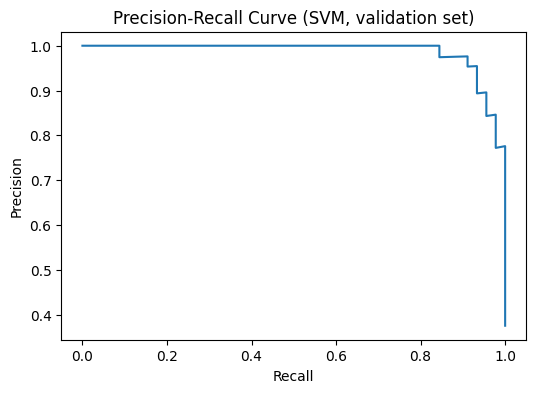

Default threshold 0.500 -> recall = 0.9333, precision = 0.9545
Chosen threshold 0.241 -> recall = 0.9556, precision = 0.8958


In [26]:
# Threshold tuning on a VALIDATION split (not test set)
# Step 1: Create inner split from training data
X_inner, X_val, y_inner, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.30, stratify=y_train, random_state=42
)

# Step 2: Retrain best model (SVM) on inner training set
threshold_model = SVC(**svm_grid.best_params_, class_weight="balanced",
                      probability=True, random_state=42)
threshold_model.fit(X_inner, y_inner)

# Step 3: Get predicted probabilities on validation set
y_val_proba = threshold_model.predict_proba(X_val)[:, 1]

# Step 4: Plot precision-recall curve
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

plt.figure(figsize=(6, 4))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (SVM, validation set)")
plt.show()


# Step 5: Find threshold where recall >= 0.95
candidates = thresholds[recalls[:-1] >= 0.95]
chosen_threshold = candidates.max()

for label, t in [("Default", 0.5), ("Chosen", chosen_threshold)]:
    y_val_pred = (y_val_proba >= t).astype(int)
    print(f"{label} threshold {t:.3f} -> "
          f"recall = {recall_score(y_val, y_val_pred):.4f}, "
          f"precision = {precision_score(y_val, y_val_pred):.4f}")


### 6.2 Final Recommendation <font color="red">[3 marks]</font>

**[Your Answer]:** Answer the following. Cite specific numbers from your results.

1. Which model do you recommend and why? Reference its recall, false negative count, and cross-validation stability.
2. How many false negatives does it produce on the test set? Is this clinically acceptable?
3. What is one specific limitation of your analysis? (Not "more data." Be concrete, e.g., "the dataset has only 569 samples, which limits the reliability of cross-validation estimates.")


*Write your answers here:*

1. I recommend the SVM (RBF kernel, C=1). It had the best test recall (0.969) and missed only 2 of 64 cancers, fewer than any other model. It was also stable in cross-validation, with a mean recall of 0.952 and a small spread (std 0.028).

2. The SVM produces 2 false negatives on the test set, so 2 patients with cancer would be told they are fine. That is not acceptable if the model makes the final call, because each one is a missed cancer. It is acceptable as a screening tool that flags cases for a doctor to review

3. The test set has only 64 malignant cases, so each missed cancer moves recall by about 1.6 percentage points.


---
# PART 2: Multiclass Classification, Wine Dataset

## Context

The Wine dataset contains chemical analysis results of wines from the same region of Italy, grown from **three different cultivars** (grape varieties). The task: predict the cultivar (class 0, 1, or 2) based on 13 chemical attributes like alcohol content, malic acid, and flavanoids.

**Why Macro-F1 matters here:** No single wine class is more "dangerous" to misclassify. All three matter equally. Macro-averaged F1-score treats each class the same regardless of size.


## Stage 1: Data and Package Loading

<font color="red">**[2 marks]**</font>

Load the Wine dataset from `sklearn.datasets`. Convert to a DataFrame. Separate features and target. Import `MLPClassifier`.


In [27]:
# Pre-imported for Part 2
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_wine

# Load wine dataset
wine_data = load_wine()
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

X_wine = wine_df
y_wine = wine_data.target

wine_df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## Stage 2: Data Understanding

<font color="red">**[6 marks]**</font>


### 2.1 Basic Inspection <font color="red">[2 marks]</font>

Display the shape, first few rows, data types, and check for missing values.


In [28]:
# Inspect the wine dataset
print("Shape of X_wine:", X_wine.shape)
print("Shape of y_wine:", y_wine.shape)
print()
print("Data types:")
print(wine_df.dtypes.value_counts())
print()
print("Missing values in X_wine:", wine_df.isnull().sum().sum())
print("Missing values in y_wine:", pd.Series(y_wine).isnull().sum())

wine_df.head()

Shape of X_wine: (178, 13)
Shape of y_wine: (178,)

Data types:
float64    13
Name: count, dtype: int64

Missing values in X_wine: 0
Missing values in y_wine: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


### 2.2 Class Distribution <font color="red">[2 marks]</font>

How many wines in each class? Visualise with a bar plot.


0    59
1    71
2    48
Name: count, dtype: int64


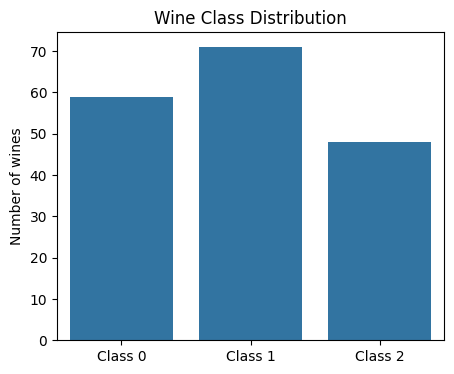

In [29]:
# Wine class distribution
wine_counts = pd.Series(y_wine).value_counts().sort_index()
print(wine_counts)

plt.figure(figsize=(5, 4))
sns.barplot(x=["Class 0", "Class 1", "Class 2"], y=wine_counts.values)
plt.ylabel("Number of wines")
plt.title("Wine Class Distribution")
plt.show()




### 2.3 Feature Analysis <font color="red">[2 marks]</font>

Look at the feature ranges using `.describe()`. Some features range in the hundreds, others below 1. Then plot a **correlation heatmap** to see which features move together.


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


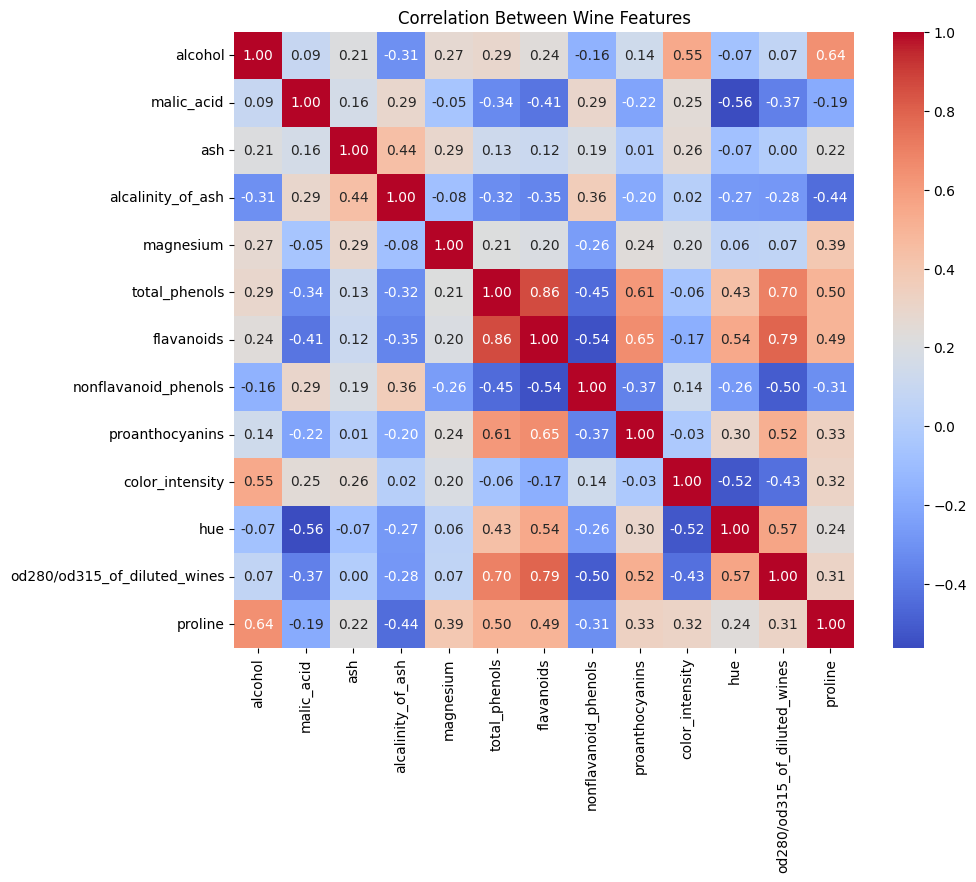

In [30]:
# Summary statistics
display(wine_df.describe())

# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(wine_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Between Wine Features")
plt.show()

### ✍️ Interpretation Checkpoint

**[Your Answer]:**
1. Are the three wine classes roughly balanced?
2. Looking at the feature ranges, do some features dominate others in scale? What does this imply for models like KNN and SVM?


*Write your answers here:*

1. Roughly, yes. Class 0 has 59 wines (33%), class 1 has 71 (40%) and class 2 has 48 (27%). Class 2 is the smallest, but no class is badly outnumbered.

2. Yes, a few features are on much bigger scales. proline ranges from 278 to 1680 and magnesium from 70 to 162, while nonflavanoid_phenols stays between 0.13 and 0.66 and hue between 0.48 and 1.71. KNN and SVM work with distances between points, so without scaling, proline would outweigh almost every other feature just because its numbers are bigger. We need to scale the features before training these models.


## Stage 3: Data Preprocessing

<font color="red">**[4 marks]**</font>


### 3.1 Split and Scale <font color="red">[2 marks]</font>

Stratified train-test split (70-30, `random_state=42`), then `StandardScaler` fit on training data only. Stratification for handling any slight class imbalance in the data.

> **Reminder:** Decision Trees don't need scaling, but KNN, SVM, MLP, and Logistic Regression all do. We scale for all models here.


In [31]:
# Stratified train-test split
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.30, stratify=y_wine, random_state=42
)

In [32]:
# Scale features: fit on train, transform both
scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)

### 3.2 Verify Preparation <font color="red">[2 marks]</font>

Print shapes and class distributions for both splits.


In [33]:
# Verify preparation
print("X_train_wine_scaled shape:", X_train_wine_scaled.shape)
print("X_test_wine_scaled shape:", X_test_wine_scaled.shape)
print()
print("Training set class distribution (proportion):")
print(pd.Series(y_train_wine).value_counts(normalize=True).sort_index().round(3))
print()
print("Test set class distribution (proportion):")
print(pd.Series(y_test_wine).value_counts(normalize=True).sort_index().round(3))


X_train_wine_scaled shape: (124, 13)
X_test_wine_scaled shape: (54, 13)

Training set class distribution (proportion):
0    0.331
1    0.403
2    0.266
Name: proportion, dtype: float64

Test set class distribution (proportion):
0    0.333
1    0.389
2    0.278
Name: proportion, dtype: float64


## Stage 4: Model Training and Hyperparameter Tuning

<font color="red">**[20 marks]**</font>

Train **five classifiers** on the wine dataset. Use `GridSearchCV` with `scoring='f1_macro'` and `cv=5` for each. Use the `evaluate_model()` helper from Part 1.

> **Key difference from Part 1:** We optimise for `f1_macro` instead of `recall`, because all classes matter equally.


### 4.1 Logistic Regression <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.01, 0.1, 1, 10]`
- `max_iter`: `10000`
- `random_state`: `42`


In [34]:
# Logistic Regression for Wine
lr_wine_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=10000, random_state=42),
    param_grid={"C": [0.01, 0.1, 1, 10]},
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)
lr_wine_grid.fit(X_train_wine_scaled, y_train_wine)
print("Best parameters:", lr_wine_grid.best_params_)
print("Best CV macro-F1:", round(lr_wine_grid.best_score_, 4))
print()

best_lr_wine = lr_wine_grid.best_estimator_
y_pred_lr_wine = best_lr_wine.predict(X_test_wine_scaled)
evaluate_model("Logistic Regression", y_test_wine, y_pred_lr_wine, average="macro")



Best parameters: {'C': 0.1}
Best CV macro-F1: 0.9834

===== Logistic Regression =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0
Confusion matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]


### 4.2 K-Nearest Neighbours <font color="red">[3 marks]</font>

**Hyperparameters:**
- `n_neighbors`: `[3, 5, 7, 9, 11]`
- `weights`: `['uniform', 'distance']`


In [35]:
# KNN for Wine
knn_wine_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid={
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
    },
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)
knn_wine_grid.fit(X_train_wine_scaled, y_train_wine)
print("Best parameters:", knn_wine_grid.best_params_)
print("Best CV macro-F1:", round(knn_wine_grid.best_score_, 4))
print()

best_knn_wine = knn_wine_grid.best_estimator_
y_pred_knn_wine = best_knn_wine.predict(X_test_wine_scaled)
evaluate_model("KNN", y_test_wine, y_pred_knn_wine, average="macro")


Best parameters: {'n_neighbors': 11, 'weights': 'uniform'}
Best CV macro-F1: 0.9776

===== KNN =====
Accuracy : 0.963
Precision: 0.9608
Recall   : 0.9683
F1-score : 0.9625
Confusion matrix:
[[18  0  0]
 [ 0 19  2]
 [ 0  0 15]]


### 4.3 Decision Tree <font color="red">[3 marks]</font>

**Hyperparameters:**
- `max_depth`: `[3, 5, 7, 10, None]`
- `min_samples_split`: `[2, 5, 10]`
- `min_samples_leaf`: `[1, 2, 4]`
- `random_state`: `42`


In [36]:
# Decision Tree for Wine
dt_wine_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid={
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)
dt_wine_grid.fit(X_train_wine_scaled, y_train_wine)
print("Best parameters:", dt_wine_grid.best_params_)
print("Best CV macro-F1:", round(dt_wine_grid.best_score_, 4))
print()

best_dt_wine = dt_wine_grid.best_estimator_
y_pred_dt_wine = best_dt_wine.predict(X_test_wine_scaled)
evaluate_model("Decision Tree", y_test_wine, y_pred_dt_wine, average="macro")


Best parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best CV macro-F1: 0.88

===== Decision Tree =====
Accuracy : 0.963
Precision: 0.971
Recall   : 0.9593
F1-score : 0.9638
Confusion matrix:
[[17  1  0]
 [ 0 21  0]
 [ 0  1 14]]


### 4.4 Support Vector Machine <font color="red">[3 marks]</font>

**Hyperparameters:**
- `C`: `[0.1, 1, 10]`
- `kernel`: `['linear', 'rbf']`
- `gamma`: `['scale', 'auto']`
- `random_state`: `42`


In [37]:
# SVM for Wine
svm_wine_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid={
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"],
    },
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)
svm_wine_grid.fit(X_train_wine_scaled, y_train_wine)
print("Best parameters:", svm_wine_grid.best_params_)
print("Best CV macro-F1:", round(svm_wine_grid.best_score_, 4))
print()

best_svm_wine = svm_wine_grid.best_estimator_
y_pred_svm_wine = best_svm_wine.predict(X_test_wine_scaled)
evaluate_model("SVM", y_test_wine, y_pred_svm_wine, average="macro")


Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV macro-F1: 0.992

===== SVM =====
Accuracy : 0.9815
Precision: 0.9848
Recall   : 0.9778
F1-score : 0.9808
Confusion matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  1 14]]


### 4.5 Multi-Layer Perceptron (MLP) <font color="red">[8 marks]</font>

The MLP is a neural network. Unlike the previous models, you control the **architecture**: how many layers, how many neurons per layer.

**Hyperparameters to tune:**
- `hidden_layer_sizes`: Try `[(50,), (100,), (50, 50), (100, 50)]`. Each tuple defines layer widths.
- `activation`: Try `['relu', 'tanh']`. The non-linear function at each neuron.
- `alpha`: Try `[0.0001, 0.001, 0.01]`. L2 regularisation to prevent overfitting.
- Set `max_iter=2000`, `random_state=42`, and `early_stopping=True`

> **What is early stopping?** It monitors validation performance during training and stops when performance plateaus. Without it, the network keeps training until it memorises the data.


In [38]:
# MLP for Wine
mlp_wine_grid = GridSearchCV(
    estimator=MLPClassifier(max_iter=2000, random_state=42, early_stopping=True),
    param_grid={
        "hidden_layer_sizes": [(50,), (100,), (50, 50), (100, 50)],
        "activation": ["relu", "tanh"],
        "alpha": [0.0001, 0.001, 0.01],
    },
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)
mlp_wine_grid.fit(X_train_wine_scaled, y_train_wine)
print("Best parameters:", mlp_wine_grid.best_params_)
print("Best CV macro-F1:", round(mlp_wine_grid.best_score_, 4))

best_mlp_wine = mlp_wine_grid.best_estimator_

Best parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (100,)}
Best CV macro-F1: 0.9136


In [39]:
# Evaluate MLP on test set
y_pred_mlp_wine = best_mlp_wine.predict(X_test_wine_scaled)
evaluate_model("MLP", y_test_wine, y_pred_mlp_wine, average="macro")


===== MLP =====
Accuracy : 0.8519
Precision: 0.872
Recall   : 0.873
F1-score : 0.8506
Confusion matrix:
[[18  0  0]
 [ 5 13  3]
 [ 0  0 15]]


### ✍️ MLP Interpretation

**[Your Answer]:**
1. What architecture (hidden layer sizes) performed best? Why do you think that configuration won?
2. Did the MLP outperform the classical models? By how much in macro-F1?
3. What role does `alpha` (regularisation) play? What happens if it is set too high? Too low?


*Write your answers here:*

1. The best architecture was a single hidden layer of 100 neurons, (100,), with tanh and alpha=0.0001 (CV macro-F1 0.914). The wine data is small and fairly easy to separate, so one wide layer was enough. The two-layer networks had more weights to learn from only 124 training wines, and early stopping gave them less time to learn them. The small (50,) network did worst (best CV macro-F1 0.643).

2. No. The MLP was the weakest model, with a test macro-F1 of 0.851. Logistic Regression scored 1.000 and SVM 0.981, so the MLP was about 0.15 behind the best classical model. The main cause is early stopping: it held back 10% of the training data (only 12 wines) to decide when to stop, and training ended after just 28 rounds. Trained without early stopping, the same network reached 0.983, about the same as SVM.

3. Alpha is a penalty on large weights that keeps the network from memorising the training data. If it's too high, the weights get pushed towards zero and the network becomes too simple to learn the pattern (underfitting). If it's too low, nothing holds the network back and it can overfit a small dataset like this one. Here the three values gave almost the same average CV score (0.774 to 0.775), so the layer sizes mattered much more than alpha.


## Stage 5: Model Comparison

<font color="red">**[8 marks]**</font>


### 5.1 Comparison Table <font color="red">[3 marks]</font>

Create a DataFrame comparing all five models on the **test set**:
- Accuracy
- Macro-Precision
- Macro-Recall
- Macro-F1-Score


In [40]:
# Comparison table for all 5 wine models
wine_predictions = {
    "Logistic Regression": y_pred_lr_wine,
    "KNN": y_pred_knn_wine,
    "Decision Tree": y_pred_dt_wine,
    "SVM": y_pred_svm_wine,
    "MLP": y_pred_mlp_wine,
}

rows = []
for name, y_pred in wine_predictions.items():
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_wine, y_pred),
        "Macro-Precision": precision_score(y_test_wine, y_pred, average="macro"),
        "Macro-Recall": recall_score(y_test_wine, y_pred, average="macro"),
        "Macro-F1": f1_score(y_test_wine, y_pred, average="macro"),
    })

wine_comparison_df = pd.DataFrame(rows).round(4)
wine_comparison_df



,Model,Accuracy,Macro-Precision,Macro-Recall,Macro-F1
0,Logistic Regression,1.0000,1.0000,1.0000,1.0000
1,KNN,0.9630,0.9608,0.9683,0.9625
2,Decision Tree,0.9630,0.9710,0.9593,0.9638
3,SVM,0.9815,0.9848,0.9778,0.9808
4,MLP,0.8519,0.8720,0.8730,0.8506


### 5.2 Visualise Comparison <font color="red">[2 marks]</font>

Bar chart comparing Macro-F1 scores across all five models.


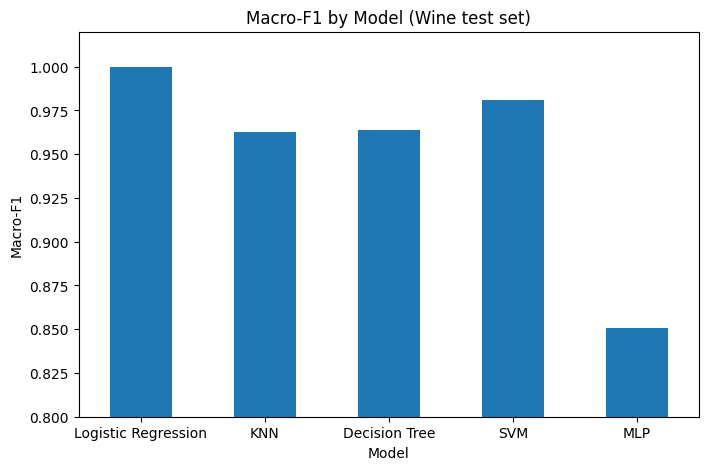

In [41]:
# Macro-F1 bar chart
wine_comparison_df.plot(x="Model", y="Macro-F1", kind="bar", legend=False, figsize=(8, 5))
plt.ylim(0.8, 1.02)
plt.ylabel("Macro-F1")
plt.title("Macro-F1 by Model (Wine test set)")
plt.xticks(rotation=0)
plt.show()


### 5.3 Cross-Validation Stability <font color="red">[3 marks]</font>

For **all five models**, run 5-fold cross-validation with `scoring='f1_macro'` on the training set. Print the mean and standard deviation for each.


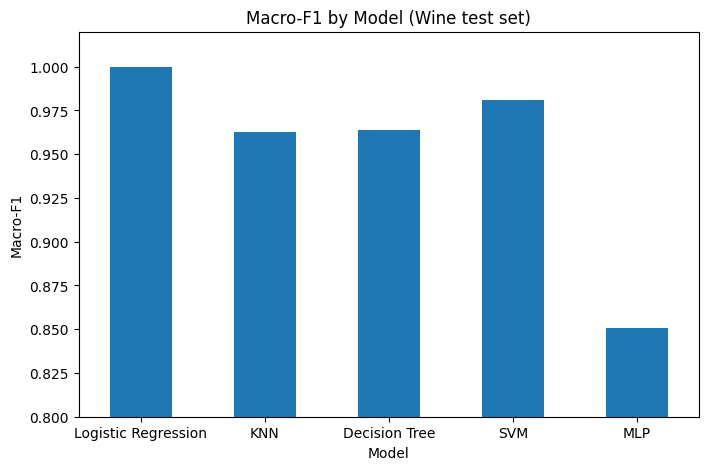

In [42]:
# Cross-validation stability for all 5 wine models
wine_comparison_df.plot(x="Model", y="Macro-F1", kind="bar", legend=False, figsize=(8, 5))
plt.ylim(0.8, 1.02)
plt.ylabel("Macro-F1")
plt.title("Macro-F1 by Model (Wine test set)")
plt.xticks(rotation=0)
plt.show()


### ✍️ Classical vs Neural Comparison

**[Your Answer]:**
1. Which classical model performed best on macro-F1? Why might that be?
2. Did the MLP beat the classical models by a clear margin, or was the gap small?
3. When would you choose a simpler model like Logistic Regression over the MLP, even if the MLP scores slightly higher?


*Write your answers here:*

1. On the test set, Logistic Regression was best with a perfect macro-F1 of 1.000. In cross-validation, SVM was best (0.992, std 0.016). The wine classes are very different chemically (for example in flavanoids and proline), so once the features are scaled, simple boundaries separate them almost perfectly.

2. No, it was clearly the worst. Its test macro-F1 was 0.851, about 0.15 below Logistic Regression (1.000), and its CV score (0.914) was also below every classical model except the Decision Tree.

3. I would choose Logistic Regression, when I need to explain the predictions, because each feature gets a weight you can read. It's also faster, needs less tuning and is steadier on small datasets.


## Stage 6: Final Recommendation

<font color="red">**[5 marks]**</font>


### 6.1 Final Model Selection <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Which model do you recommend as the best **classical** model for the wine dataset? Cite its macro-F1 score.
2. Which model do you recommend as the best **overall** model? Consider performance vs interpretability.
3. If a winemaker wanted to understand *why* a wine was classified as a certain cultivar, which model would you recommend and why?


*Write your answers here:*

1. The SVM (RBF kernel, C=1). It had the highest CV macro-F1 (0.992) with the smallest spread (std 0.016), and a test macro-F1 of 0.981. Logistic Regression scored a perfect 1.000 on the test set, but the CV score is based on more splits, so it's the more reliable guide.

2. Logistic Regression. It's almost as accurate as SVM (CV 0.983, test 1.000), and it's much easier to understand, because you can see how much each chemical feature pushes a wine towards each class. The MLP was both less accurate and harder to interpret, so it doesn't win on either count.

3. I would recomment the Decision Tree algorithm. The tuned tree has a depth of 3, so every prediction is at most three simple questions, like "Is proline above X? Are flavanoids above Y?". Anyone can follow that without any maths. It's slightly less accurate (test macro-F1 0.964), but it explains its decisions best.


### 6.2 Underfitting vs Overfitting Study <font color="red">[2 marks]</font>

Train three Decision Tree variants on the wine dataset:
1. `max_depth=1` with `random_state=42` (too simple, underfits)
2. `max_depth=None` with `random_state=42` (no constraints, overfits)
3. Your best tuned tree from Stage 4

For each, print the **training accuracy** and **test accuracy**. Look at the gap.


In [43]:
# Overfitting study: 3 Decision Tree variants
tree_variants = {
    "Depth 1 (underfit)": DecisionTreeClassifier(max_depth=1, random_state=42),
    "No limit (overfit)": DecisionTreeClassifier(max_depth=None, random_state=42),
    "Tuned (Stage 4)": best_dt_wine,
}

for name, tree in tree_variants.items():
    tree.fit(X_train_wine_scaled, y_train_wine)
    train_acc = accuracy_score(y_train_wine, tree.predict(X_train_wine_scaled))
    test_acc = accuracy_score(y_test_wine, tree.predict(X_test_wine_scaled))
    print(f"{name:<20} train = {train_acc:.4f}   test = {test_acc:.4f}   gap = {train_acc - test_acc:.4f}")


Depth 1 (underfit)   train = 0.6613   test = 0.6111   gap = 0.0502
No limit (overfit)   train = 1.0000   test = 0.9630   gap = 0.0370
Tuned (Stage 4)      train = 0.9919   test = 0.9630   gap = 0.0290


### ✍️ Underfitting vs Overfitting

**[Your Answer]:**
1. Which variant underfits? How can you tell from the train/test accuracy?
2. Which variant overfits? What is the gap between train and test accuracy?
3. How does the tuned model sit between these two extremes?


*Write your answers here:*

1. The depth-1 tree. It scores low on both training (0.661) and test (0.611) data, which means it hasn't learned the pattern at all. A depth-1 tree asks only one question and ends in two groups, so it can never predict one of the three wine classes.

2. The unlimited tree. It scores a perfect 1.000 on training data because it grows until it has memorised every training wine. Its test accuracy is 0.963, a gap of 0.037. The drop is small here because the wine classes are easy to separate, but perfect training accuracy is the typical warning sign.

3. In between. It scores 0.992 on training and 0.963 on test, the smallest gap of the three (0.029). It gets the same test accuracy as the unlimited tree while being much simpler, so it's less likely to fail on new wines.


---
## Indicative Mark Summary

> **Reminder:** These marks are for self-assessment only. They do not count towards your final grade.

| Section | Topic | Marks |
|---------|-------|-------|
| **Part 1** | | **55** |
| Stage 1 | Data Loading | 3 |
| Stage 2 | Data Understanding + Interpretation | 8 |
| Stage 3 | Preprocessing | 7 |
| Helper + Tutorial | Evaluation Function, GridSearchCV Walkthrough | 0 |
| Stage 4 | Model Training and Tuning (4 models) | 23 |
| Stage 5 | Model Comparison + Feature Importance | 9 |
| Stage 6 | Final Model Selection | 5 |
| **Part 2** | | **45** |
| Stage 1 | Data Loading | 2 |
| Stage 2 | Data Understanding + Interpretation | 6 |
| Stage 3 | Preprocessing | 4 |
| Stage 4 | Model Training and Tuning (5 models, incl. MLP) | 20 |
| Stage 5 | Model Comparison | 8 |
| Stage 6 | Final Recommendation | 5 |
| | **Total** | **100** |

---
*End of Practice Assignment*
